In [1]:
from astropy.io import ascii
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [2]:
filename='M101phot_unbinned_azi.dat'
if not os.path.isfile(filename):
 m101= ascii.read('https://burro.case.edu/Academics/Astr323/HW/HW3/'+filename)
 ascii.write(m101, filename, overwrite=True)
else:
 m101=ascii.read(filename)


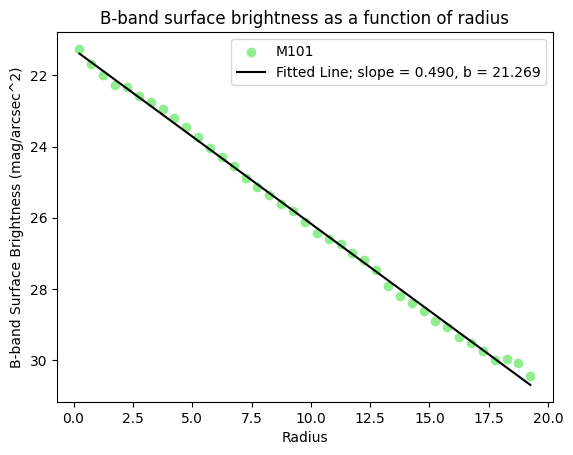

In [38]:
plt.scatter(m101['R'], m101['muB'], color = 'lightgreen', label = "M101")

slope, intercept = np.polyfit(m101['R'], m101['muB'], deg=1)
y_fit = slope * m101['R'] + intercept

plt.plot(m101['R'], y_fit, color='black', label=f'Fitted Line; slope = {slope:.3f}, b = {intercept:.3f}')
plt.legend()

plt.xlabel('Radius')
plt.ylabel('B-band Surface Brightness (mag/arcsec^2)')
plt.title("B-band surface brightness as a function of radius")
plt.gca().invert_yaxis()

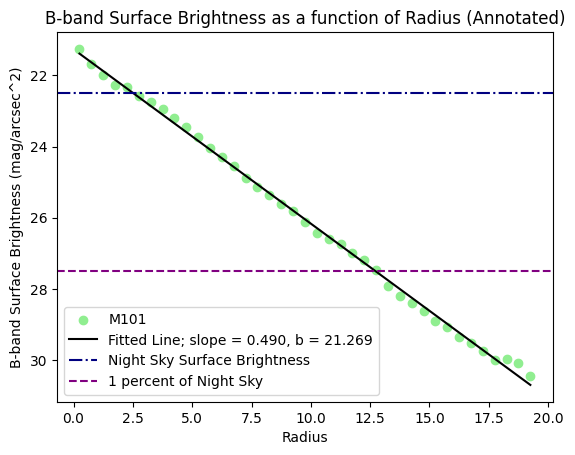

In [41]:
plt.scatter(m101['R'], m101['muB'], color = 'lightgreen', label = "M101")

slope, intercept = np.polyfit(m101['R'], m101['muB'], deg=1)
y_fit = slope * m101['R'] + intercept

plt.plot(m101['R'], y_fit, color='black', label=f'Fitted Line; slope = {slope:.3f}, b = {intercept:.3f}')


plt.axhline(y =22.5, color='navy', linestyle='-.', label = "Night Sky Surface Brightness")
plt.axhline(y =27.5, color='purple', linestyle='--', label = "1 percent of Night Sky")

plt.legend()

plt.xlabel('Radius')
plt.ylabel('B-band Surface Brightness (mag/arcsec^2)')
plt.title("B-band Surface Brightness as a function of Radius (Annotated)")
plt.gca().invert_yaxis()

In [4]:
L = 2.5e10
M_B_sun = 5.44
mu25 = 25
const = 21.572
kpc_to_pc = 1e3

hR_kpc = np.linspace(1,30,200)
hR_pc = hR_kpc * kpc_to_pc

I0 = L / (2 * np.pi * hR_pc**2)
mu0 = M_B_sun + const - 2.5 * np.log10(I0)

R25_kpc = hR_kpc * (mu25 - mu0) / 1.086

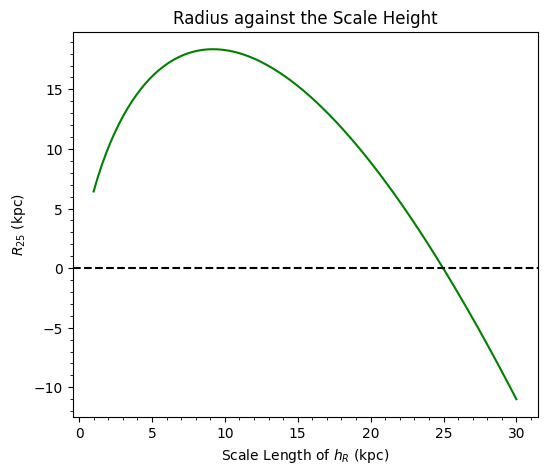

In [22]:
plt.figure(figsize=(6,5))
plt.plot(hR_kpc, R25_kpc, color = "green")
plt.xlabel(r"Scale Length of $h_R$ (kpc)")
plt.ylabel(r"$R_{25}$ (kpc)")
plt.title("Radius against the Scale Height")
plt.minorticks_on()
plt.axhline(color='k', linestyle='--')

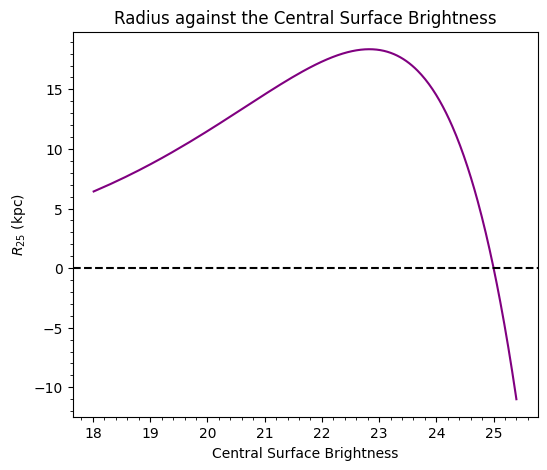

In [21]:
plt.figure(figsize=(6,5))
plt.plot(mu0, R25_kpc, color = "purple")
plt.xlabel("Central Surface Brightness")
plt.ylabel(r"$R_{25}$ (kpc)")
plt.title("Radius against the Central Surface Brightness")
plt.axhline(color='k', linestyle='--')
plt.minorticks_on()